In [55]:
#Name:Samiksha Sanjay Pharakate
#PRN:2324000725
#B32
#Experiment 5

Image loaded: 740x1109 pixels with 3 channels
[[[226 243 251]
  [226 243 251]
  [226 243 251]
  ...
  [174 205 213]
  [174 205 215]
  [174 205 215]]

 [[226 243 251]
  [226 243 251]
  [226 243 251]
  ...
  [174 205 213]
  [174 205 215]
  [174 205 215]]

 [[226 243 251]
  [226 243 251]
  [226 243 251]
  ...
  [174 205 213]
  [174 205 215]
  [174 205 215]]

 ...

 [[140 186 105]
  [140 186 105]
  [140 186 105]
  ...
  [ 95   5   2]
  [ 96   6   3]
  [ 97   7   4]]

 [[140 186 105]
  [140 186 105]
  [140 186 105]
  ...
  [ 94   4   1]
  [ 95   5   2]
  [ 96   6   3]]

 [[140 186 105]
  [140 186 105]
  [140 186 105]
  ...
  [ 93   3   0]
  [ 94   4   1]
  [ 95   5   2]]]


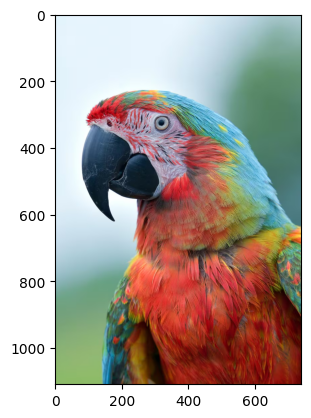

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_color = cv2.imread('IPCV.jpg')

if img_color is None:
    print("Error: Could not find image. Check the file path!")
else:
    height, width, channels = img_color.shape
    print(f"Image loaded: {width}x{height} pixels with {channels} channels")

img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

print(img_rgb)
img_rgb
plt.imshow(img_rgb)

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
if img_rgb is None:
    print("Error: Could not load image.")
else:
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3) # Vertical edges

    sobel_combined_raw = cv2.magnitude(sobel_x, sobel_y)
    # Normalize the Sobel result for consistent display as an 8-bit image
    sobel_combined = cv2.normalize(sobel_combined_raw, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

In [37]:
if img_rgb is None:
    print("Error: img_rgb is not loaded.")
else:
    img_gray_canny = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    Canny_detection = cv2.Canny(img_gray_canny, 100, 200)

In [40]:
titles = ['Original Image', 'Sobel Combined','Canny Edge Detection']
images = [img_rgb, sobel_combined,Canny_detection]

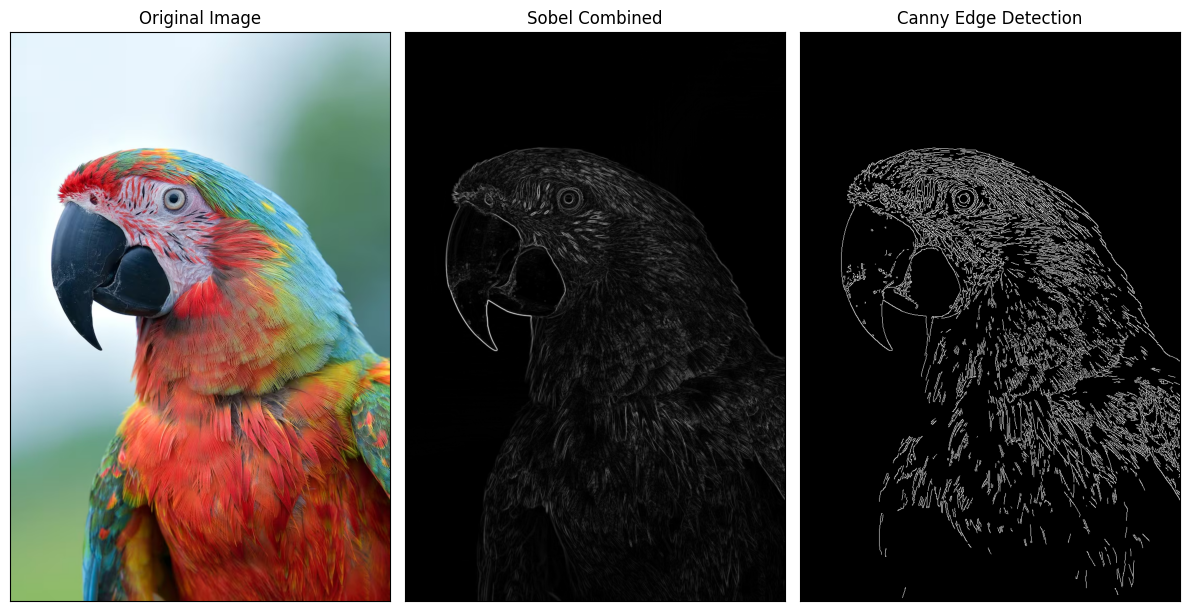

In [44]:
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(1, len(images), i+1)
    if titles[i] == 'Original Image': # Original image is RGB
        plt.imshow(images[i])
    else: # Sobel and Canny are grayscale
        plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

In [48]:
gaussian_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
log_edges = cv2.Laplacian(gaussian_blur, cv2.CV_64F)
log_edges = np.uint8(np.absolute(log_edges))

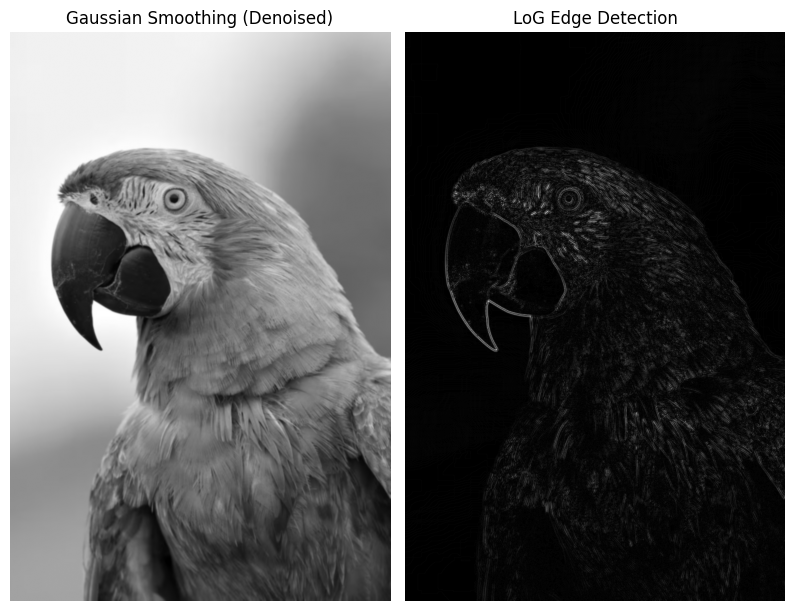

In [50]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 2)
plt.imshow(gaussian_blur, cmap='gray')
plt.title('Gaussian Smoothing (Denoised)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(log_edges, cmap='gray')
plt.title('LoG Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()